# Эксперимент: Зависимость числа итераций метода сопряженных градиентов от числа обусловленности и размерности пространства

In [7]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
sys.path.append('../src')
import dependency_task as template
from methods_wrappers import cg_wrapper_quadratic

In [8]:
# Параметры
n_vals = [10, 15, 20, 50, 100]
kappa_vals = np.logspace(0, 3, 15)  # от 1 до 1000
n_repeats = 5
cg = template.experiment_conditioning(cg_wrapper_quadratic, "CG",
                                 n_vals, kappa_vals, n_repeats,
                                 tolerance=1e-6, max_iter=5000)

CG: n= 10, κ=   1.00 → 1.0±0.0
CG: n= 10, κ=   1.64 → 6.6±0.5
CG: n= 10, κ=   2.68 → 8.0±0.6
CG: n= 10, κ=   4.39 → 8.2±0.4
CG: n= 10, κ=   7.20 → 8.0±0.0
CG: n= 10, κ=  11.79 → 8.2±0.4
CG: n= 10, κ=  19.31 → 8.6±0.8
CG: n= 10, κ=  31.62 → 8.4±0.5
CG: n= 10, κ=  51.79 → 8.4±0.8
CG: n= 10, κ=  84.83 → 8.8±0.7
CG: n= 10, κ= 138.95 → 8.2±0.4
CG: n= 10, κ= 227.58 → 8.4±0.5
CG: n= 10, κ= 372.76 → 9.2±1.0
CG: n= 10, κ= 610.54 → 9.0±0.6
CG: n= 10, κ=1000.00 → 9.4±0.5
CG: n= 15, κ=   1.00 → 1.0±0.0
CG: n= 15, κ=   1.64 → 7.0±0.0
CG: n= 15, κ=   2.68 → 9.4±0.5
CG: n= 15, κ=   4.39 → 11.2±0.4
CG: n= 15, κ=   7.20 → 13.2±0.7
CG: n= 15, κ=  11.79 → 13.2±0.4
CG: n= 15, κ=  19.31 → 13.2±0.4
CG: n= 15, κ=  31.62 → 13.4±0.5
CG: n= 15, κ=  51.79 → 13.6±0.8
CG: n= 15, κ=  84.83 → 13.8±0.7
CG: n= 15, κ= 138.95 → 14.2±0.4
CG: n= 15, κ= 227.58 → 15.2±1.0
CG: n= 15, κ= 372.76 → 15.0±0.9
CG: n= 15, κ= 610.54 → 16.6±0.8
CG: n= 15, κ=1000.00 → 16.2±0.7
CG: n= 20, κ=   1.00 → 1.0±0.0
CG: n= 20, κ=   1.64 → 7.0±

График сохранён: /home/vchepelin/Repositories/opt_project_lab_2/plots/2_2_compare.png


<Axes: title={'center': 'Зависимость итераций от κ и n'}, xlabel='$\\kappa$', ylabel='Итерации'>

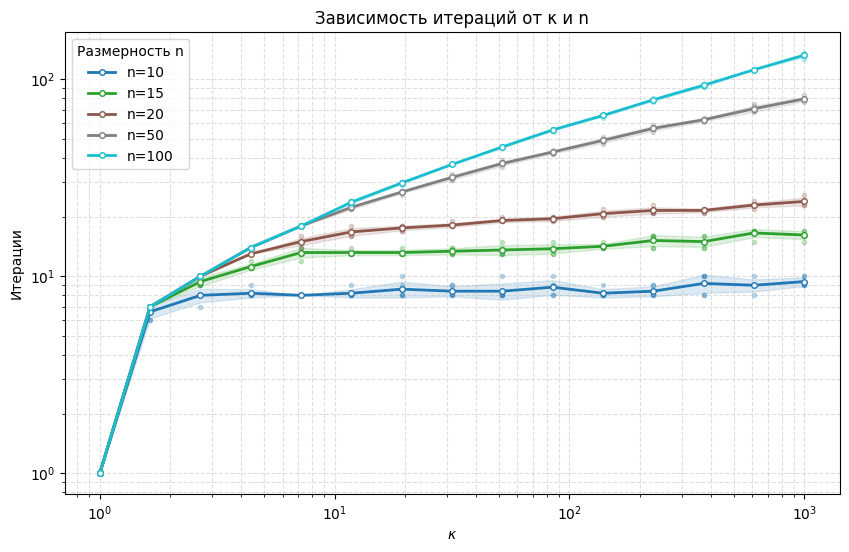

In [9]:
template.plot_conditioning_results( {'results': cg, 'n_values': n_vals, 'kappa_values': kappa_vals},  
                                    "Зависимость итераций от κ и n", save_to_disk = True, filename = "2_2_compare")

Выводы:
1. Число итераций сверху ограниченно размерностью и $\sqrt(k)$
2. Сравнение методов
   - При $\kappa = 1$ оба метода сходятся быстро (GD за ~50 итераций, CG за ~10).  
   - При $\kappa \geq 100$ CG становится предпочтительнее по числу итераций.  
   - Дополнительным преимуществом CG является отсутствие необходимости хранить матрицу $A$: достаточно уметь вычислять $A v$. Это позволяет решать задачи огромной размерности, где явное формирование $A$ невозможно.

3. При решении систем линейных уравнений CG даёт значительный выигрыш во времени и памяти.